# dN/dR Distributions from sample galaxy SEDs

Purpose of this notebook is to look at how the dN/dR profile changes when accounting for real galaxy SEDs, as compared to a flat dNdR distribution which was assumed in some previous analysis

Created - 05/23/2025
Last edited - 08/29/2025




In [2]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import galsim
import os
from astropy.table import Table



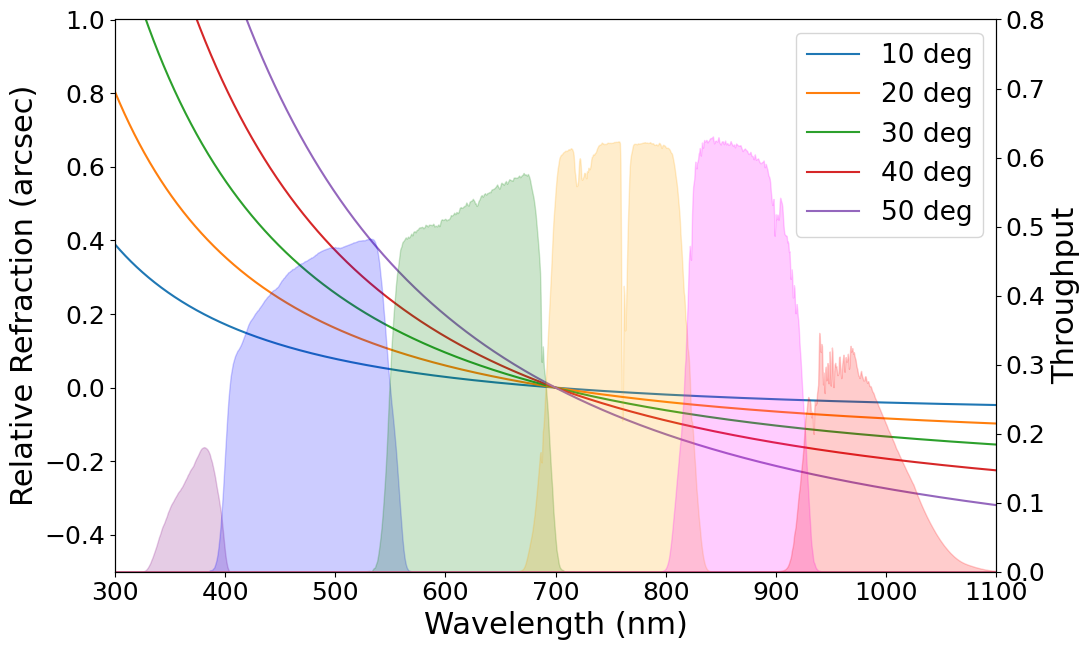

In [3]:
#checking my understanding of the dcr.get_refraction function by 
#recreating the plot 1 from the Impact of Atmospheric Chromatic Effects on Weak Lensing Measurements (Meyers and Burchat, 2018)
zeniths = [10, 20, 30, 40, 50]
# zeniths = [35]
dwvl = 0.5
wavelengths = np.arange(290, 1160, dwvl)

fig, ax1 = plt.subplots(figsize = (11, 6.6))

filters = ['total_u.dat','total_g.dat','total_r.dat','total_i.dat','total_z.dat','total_y.dat']
colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}
script_dir = os.getcwd()
folder = os.path.join(script_dir, 'filter_files/')

ax2 = ax1.twinx()
for i, filter_ in enumerate(filters):
    path = folder + filter_
    data = np.loadtxt(path).T
    band = list(colors.keys())[i]
    ax2.fill_between(data[0], data[1], np.zeros(len(data[1])), label = filter_, alpha = 0.2, color = colors[band])

    

for zenith in zeniths:
    refraction = galsim.dcr.get_refraction(
            wavelengths,
            zenith_angle=zenith * galsim.degrees,
            pressure=70.0,  # kPa
            temperature=293.15,  # K
            H2O_pressure=0.0,  # kPa
            ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    refraction_0 = galsim.dcr.get_refraction(
            700,
            zenith_angle=zenith * galsim.degrees,
            pressure=70.0,  # kPa
            temperature=293.15,  # K
            H2O_pressure=0.0,  # kPa
            ) * 180 * 3600 / np.pi #convert from radians to arcsec

    
    dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
    wavelengths_midpoints = wavelengths[0:-1] + dwvl/2
    
    ax1.plot(wavelengths, refraction - refraction_0, label = f'{zenith} deg')
    # plt.plot(wavelengths_midpoints, dR_dwvl, '--')


ax1.set_xlim(300, 1100)
ax1.set_ylim(-0.5, 1)
ax1.set_xlabel('Wavelength (nm)', fontsize = 22)
ax1.set_ylabel('Relative Refraction (arcsec)', fontsize = 22)
ax1.legend(fontsize = 19)
ax1.tick_params(labelsize=18)  


ax2.set_ylim(0, 0.8)
ax2.set_ylabel('Throughput', fontsize = 22)
ax2.tick_params(labelsize=18)  

plt.tight_layout()

# fig.savefig('refrac_filterthroughput.pdf')

In [4]:
#Load sample stellar SEDs
file_paths = 'starSED_files_list.txt'

#These need to be divided into two populations: kurucz and phoSimMLT
#I'm not sure why these look so different or whether they come from different simulations

wave_ku = []
flux_ku = []

wave_pho = []
flux_pho = []

with open(file_paths) as f:
    star_files = f.read().splitlines()  
    for file in star_files:
        file = 'starSEDs' + file
        t = Table.read(file, format='ascii')

        waveS = np.array(t['col1'])
        fluxS = np.array(t['col2'])
        mask = (waveS > 250)  * (waveS < 1200)

        waveS = waveS[mask]
        fluxS = fluxS[mask]

        if file.__contains__('phoSimMLT'):
            flux_pho.append(fluxS)
            if len(wave_pho) < 2:
                wave_pho = waveS
        elif file.__contains__('kurucz'):
            flux_ku.append(fluxS)
            if len(wave_ku) < 2:
                wave_ku = waveS



# for i in range(len(flux_ku)):
#     plt.plot(wave_ku, flux_ku[i], 'k-', alpha = 0.01)
# plt.xlabel('wavelength')
# plt.ylabel('Flux') 
# plt.title('Kurucz SEDs')
# plt.legend()
# plt.show()
# plt.close()

# for i in range(len(flux_pho)):
#     plt.plot(wave_pho, flux_pho[i],'k-', alpha = 0.01)
# plt.xlabel('wavelength')
# plt.ylabel('Flux') 
# plt.title('phoSimMLT SEDs')
# plt.legend()
# plt.show()






#### Before applying the filters, removed leakage from the filters by removing anything below a 0.001 throughput:

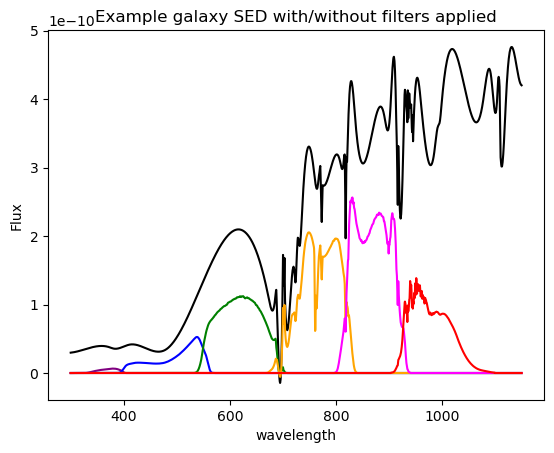

In [29]:
#Open the SED file (contains 1000 randomly sampled SEDs with magnitudes less than 26) and apply the filters

from scipy.interpolate import interp1d

def apply_filter(wvl, data, band = 'g', rm_leakage = True):
    '''
    wvl - a list of the wavelengths in angstroms
    data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
    returns data with the band filter applied to each SED
    '''
    
    filter_file = f'filter_files/total_{band}.dat'
    filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

    # remove filter leakage: set lower bound of filter to 0.001 throughput
    if rm_leakage:
        leakage_mask = filter_band[1] < 0.001
        filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
    
    func = interp1d(filter_band[0], filter_band[1])
    SED_filter = func(wvl)
    
    return data * SED_filter
    


# ---- Get stellar SEDs ----
stellar_wvl = np.array(wave_ku)
stellar_SEDs = np.array(flux_ku)
mask = (stellar_wvl > 300) * (stellar_wvl < 1150)
stellar_wvl = stellar_wvl[mask]
stellar_SEDs = stellar_SEDs[:, mask]

# Add a uniform SED at the end for testing purposes
stellar_SEDs = np.vstack([stellar_SEDs, np.ones(len(stellar_wvl))])

# increase wavelength resolution to capture filter details:
func = interp1d(stellar_wvl, stellar_SEDs)
stellar_wvl_temp = np.linspace(min(stellar_wvl), max(stellar_wvl), 8500)
stellar_wvl =stellar_wvl_temp
stellar_SEDs = func(stellar_wvl_temp)




# ---- Get galaxy SEDs ----
file = '1000SEDs.txt'
data = np.loadtxt(file)
wvl = data[0]
SEDs = data[1:]

#remove wavelengths > 1150 because that's where our filters cut off
mask = wvl < 1150
wvl = wvl[mask]
SEDs = SEDs[:, mask]

# Add a uniform SED at the end for testing purposes
SEDs = np.vstack([SEDs, np.ones(len(wvl))])

# increase wavelength resolution to capture filter details:
func = interp1d(wvl, SEDs)
wvl_temp = np.linspace(min(wvl), max(wvl), 8500)
wvl = wvl_temp
SEDs = func(wvl_temp)


    
# --- Apply filters to SEDs ----
filter_labels = ['u', 'g', 'r', 'i', 'z', 'y']


filtered_data = {}
stellar_filtered_data = {}

i = 0 #choose the index of one of the SEDs to plot (i = -1 for the uniform SED)

plt.plot(wvl, SEDs[i], 'k')

for band in filter_labels:
    filtered_data[band]= apply_filter(wvl, SEDs, band)
    stellar_filtered_data[band]= apply_filter(stellar_wvl, stellar_SEDs, band)
    plt.plot(wvl, filtered_data[band][i], color = colors[band])

plt.title('Example galaxy SED with/without filters applied')
plt.xlabel('wavelength')
plt.ylabel('Flux')
plt.show()

/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


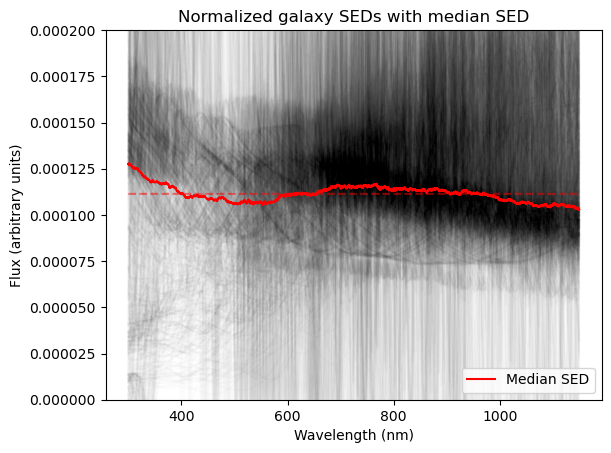

In [33]:
#Examine the average/median galaxy SED behavior

# --- Normalize each SED before calculating the average/median ---
SEDs_temp = []
for SED in SEDs:
    normalize = 1/np.sum(SED)  #normalizing by the integral of the SED (assume the wavelength step size is constant)
    plt.plot(wvl, SED*normalize, 'k-', alpha = 0.01)
    SEDs_temp.append(SED * normalize)

average_SED = np.median(SEDs_temp, axis = 0)
plt.plot(wvl, average_SED, 'r-', label = 'Median SED')
plt.plot(wvl, np.ones(len(wvl))*np.mean(average_SED), 'r--', alpha = 0.5)
plt.title('Normalized galaxy SEDs with median SED')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (arbitrary units)')
plt.legend()
plt.ylim(0, 0.0002)
plt.show()
plt.close()


SEDs = np.array(SEDs_temp) #set the galaxy SEDs to the normalized versions (optional, doesn't affect results)

In [7]:
# Get quick stellar temperature estimate from Wien's law 

from scipy.ndimage import median_filter

C2 = 1.438777e7  # hc/k in nm*K
WIEN_CONST = 2.897771955e6  # nm*K

def smooth_and_peak_many(wl_nm, fluxes, kernel=31):
    """
    Vectorized peak wavelength finder for many spectra.
    
    Parameters
    ----------
    wl_nm : (M,) array
        Wavelength grid (same for all spectra).
    fluxes : (N, M) array
        Flux values, N spectra by M wavelengths.
    kernel : int
        Median filter kernel size (odd integer).
    
    Returns
    -------
    wl_peaks : (N,) array
        Peak wavelength (nm) for each spectrum after smoothing.
    idx_peaks : (N,) array
        Index of the peak for each spectrum.
    """
    if kernel % 2 == 0:
        kernel += 1  # enforce odd size
    
    # Smooth along wavelength axis (axis=1)
    smoothed = median_filter(fluxes, size=(1, kernel), mode='nearest')
    
    # Find argmax per spectrum
    idx_peaks = np.nanargmax(smoothed, axis=1)
    wl_peaks = wl_nm[idx_peaks]
    
    return wl_peaks

def T_from_wien_peak(wl_peak_nm):
    return WIEN_CONST / wl_peak_nm

stellar_SED_peaks = smooth_and_peak_many(stellar_wvl, stellar_SEDs[:-1], kernel=31) #exclude the uniform SED at the end
stellar_temps = T_from_wien_peak(stellar_SED_peaks)

## Apply refraction effects at a chosen zenith and atmospheric conditions

At a given zenith, there is a 1-to-1 mapping of wavelengths to refraction angles.
Therefore we can go from our filtered flux distributions (dN/dwavelength) to dN/dR by doing the following:

dN/dR = dN/dwavelength * dwavelength/dR

Start by calculating dwavelength/dR as a function of wavelength then multiply this by each of our SEDs:


Text(0.5, 1.0, 'Example galaxy SED dN/dR')

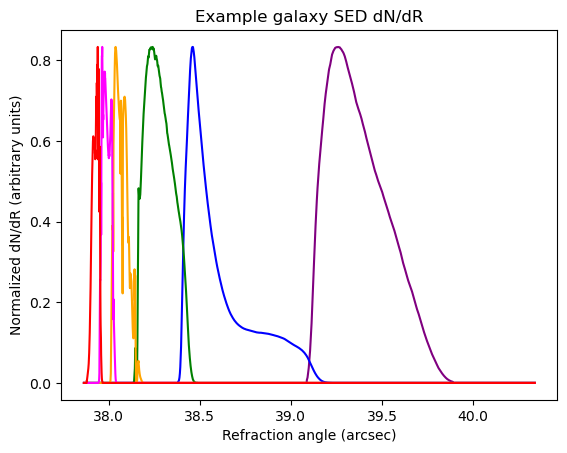

In [8]:

zenith = 45 #degrees
# dwvl = 0.1 #wavelength step
# wavelengths = np.arange(290, 1160, dwvl) 

#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067


def apply_DCR(wave, filtered_data, zenith, pressure, temperature, H2O_pressure):
    '''
    wave - list of wavelength points
    filtered_data - dictionary, keys: bands, items: list of flux throughputs for each SED as viewed in that band 

    Takes in SED data with the filter throughputs already applied, returns refraction_angles (mapped from wave) and filtered_refracted_data (the flux density over refraction angles)

    '''
    dwvl = 0.1 #wavelength step
    wave_temp = np.arange(290, 1160, dwvl)

    #Get dR/dwavelength function
    refraction = galsim.dcr.get_refraction(
        wave_temp,
        zenith_angle=zenith * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec

    dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
    wavelengths_midpoints = wave_temp[0:-1] + dwvl/2
    
    dRdwvl_func = interp1d(wavelengths_midpoints, dR_dwvl)

    #Get the refraction angle of each passed in wavelength 
    refraction_angles = galsim.dcr.get_refraction(
            wave,
            zenith_angle=zenith * galsim.degrees,
            pressure=pressure,  # kPa
            temperature=temperature,  # K
            H2O_pressure=H2O_pressure,  # kPa
            ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    
    filtered_refracted_data = {} #dictionary which will store dN/dR 
    
    for band, data in filtered_data.items():
        filtered_refracted_data[band] = np.abs(data / dRdwvl_func(wvl))

    return refraction_angles, filtered_refracted_data



refraction_angles, filtered_refracted_data = apply_DCR(wvl, filtered_data, zenith, pressure, temperature, H2O_pressure)
stellar_refraction_angles, stellar_filtered_refracted_data = apply_DCR(stellar_wvl, stellar_filtered_data, zenith, pressure, temperature, H2O_pressure)




#Examine the dN/dR results (galaxy)
for band, data in filtered_data.items():
    
    #example SED to plot
    example_refract_R = filtered_refracted_data[band][i]
    
    #plot normalized dNdR as a function of refraction
    plt.plot(refraction_angles, np.abs(example_refract_R)/max(np.abs(example_refract_R))/ 1.2, color = colors[band]) 
    

plt.xlabel('Refraction angle (arcsec)')
plt.ylabel('Normalized dN/dR (arbitrary units)')
plt.title(f'Example galaxy SED dN/dR')


In [9]:
#Calculate the mean and standard deviation of the refraction angle distributions for each of the SEDs in each filter

refrac_angle_temp = np.array(refraction_angles).T #create a vertical array for purposes of matrix multiplication below
stellar_refrac_angle_temp = np.array(stellar_refraction_angles).T #create a vertical array for purposes of matrix multiplication below

means = {}
stdevs = {}

stellar_means = {}
stellar_stdevs = {}

mean_flatdist = {}
stdev_flatdist = {}

for band, distribution in filtered_refracted_data.items():

    #--- calculate mean and stdev first for the flat SED (index = -1):
    flat_dist = distribution[-1]
    # plt.plot(refraction_angles, flat_dist)
    mean_flat = np.sum(flat_dist * refrac_angle_temp) / np.sum(flat_dist)
    mean_flatdist[band] = mean_flat
    stdev_flatdist[band] = np.sqrt(np.sum(flat_dist * (refrac_angle_temp - mean_flat)**2 ) / np.sum(flat_dist))

    #--- calculate the mean and stdev for the rest of the SEDs (galaxy and stellar):
    distribution = distribution[:-1] #don't include the flat SED (created for testing purposes) in the calculation
    stellar_distribution = stellar_filtered_refracted_data[band][:-1]
    
    #Weighted mean refraction angles within a single band for each SED
    mean = np.sum(distribution * refrac_angle_temp, axis = 1)/np.sum(distribution, axis =1)
    stellar_mean = np.sum(stellar_distribution * stellar_refrac_angle_temp, axis = 1)/np.sum(stellar_distribution, axis =1)

    means[band] = mean
    stellar_means[band] = stellar_mean

    #Weighted variance and standard deviation
    variances = np.sum(distribution * (refrac_angle_temp - mean[:, np.newaxis])**2, axis=1) / np.sum(distribution, axis=1)
    stellar_variances = np.sum(stellar_distribution * (stellar_refrac_angle_temp - stellar_mean[:, np.newaxis])**2, axis=1) / np.sum(stellar_distribution, axis=1)
    
    stdev = np.sqrt(variances)
    stdevs[band] = stdev

    stellar_stdev = np.sqrt(stellar_variances)
    stellar_stdevs[band] = stellar_stdev

    print(f'{band} (galaxy average): mean = {np.round(np.mean(mean), 4)}, stdev = {np.round(np.mean(stdev), 4)}')
    # print(f'{band} (flat SED): mean = {np.round(mean_flatdist[band], 4)}, stdev = {np.round(stdev_flatdist[band], 4)}')



u (galaxy average): mean = 39.3499, stdev = 0.1533
g (galaxy average): mean = 38.6386, stdev = 0.1744
r (galaxy average): mean = 38.2559, stdev = 0.0749
i (galaxy average): mean = 38.0768, stdev = 0.0389
z (galaxy average): mean = 37.9861, stdev = 0.0206
y (galaxy average): mean = 37.9261, stdev = 0.016


In [10]:
#Get the averaged (across SEDs) and normalized dNdR distributions:

avg_dNdR = {}
stellar_avg_dNdR = {}

for band, distribution in filtered_refracted_data.items():
    
    #galaxy
    distribution = distribution[:-1] #don't include the flat SED (created for testing purposes) in the calculation
    
    normalized_distributions = (distribution.T * np.sum(distribution, axis = 1)).T
    avg = np.median(normalized_distributions, axis = 0) 
    avg = avg / np.sum(avg) # np.max(avg) / 1.2
    avg_dNdR[band] = avg


    #stellar
    distribution = stellar_filtered_refracted_data[band][:-1] #don't include the flat SED (created for testing purposes) in the calculation
    
    normalized_distributions = (distribution.T * np.sum(distribution, axis = 1)).T
    avg = np.median(normalized_distributions, axis = 0) 
    avg = avg / np.sum(avg) # np.max(avg) / 1.2
    stellar_avg_dNdR[band] = avg



In [11]:
#Matthew's method for calculating the total refraction across a band

def calculate_filter_refractions(filter_files, directory, airmasses, dcr = True, cutoff = 8005):
    
    wavelengths = np.linspace(300, 1100, 8000)

    #get a list of zeniths from the airmasses
    zeniths = []
    for airmass in airmasses:
        if airmass > 0:
            zeniths.append(np.arccos(1 / airmass))
        else:
            zeniths.append(np.nan)  # handle zero or negative airmass values
    zeniths = np.degrees(zeniths) * u.deg
    # print(zeniths)

    #For each zenith, create a list of refractions mapped from the wavelengths
    gs_refractions = np.zeros((len(zeniths), len(wavelengths)))
    for i, zenith in enumerate(zeniths):
        gs_refraction = 3600 * np.rad2deg(galsim.dcr.get_refraction(
            wavelengths,
            zenith_angle=zenith.to_value(u.deg) * galsim.degrees,
            # pressure=70.0,  # kPa
            # temperature=293.15,  # K
            # H2O_pressure=0.0,  # kPa
            pressure=69.328,
            temperature=293.15,
            H2O_pressure=1.067,
        ))
        gs_refractions[i, :] = gs_refraction


    #For each filter, find the left and right wavelength and cross reference those to the gs_refractions table above to get the differential refraction
    filter_refractions = []
    refraction_centers = []

    for i, filter_file in enumerate(filter_files):
        #Seems like this information about the filters should just be saved once and referred back to
        data = read_filter_data_from_directory(directory, filter_file)
        wavelength = data[:(cutoff + 1), 0]
        throughput = data[:(cutoff + 1), 1]
        fwhm, left_wavelength, right_wavelength, left_idx, right_idx = calculate_fwhm(wavelength, throughput)
        
        left_idx_new = find_nearest_index(wavelengths, left_wavelength)
        right_idx_new = find_nearest_index(wavelengths, right_wavelength)

        refraction_left = gs_refractions[:, left_idx_new]
        refraction_right = gs_refractions[:, right_idx_new]
        differential_refractions = abs(refraction_left - refraction_right) if dcr else np.zeros_like(airmasses)
        refraction_center = min([refraction_left, refraction_right]) + differential_refractions/2
        filter_refractions.append(differential_refractions)
        refraction_centers.append(refraction_center)
    return filter_refractions, refraction_centers

def find_nearest_index(array, value):
    return (np.abs(array - value)).argmin()

def calculate_fwhm(wavelength, throughput, cutoff = 8005):
    max_index = np.argmax(throughput)
    half_max = throughput[max_index] / 10 #may change to actual half maximum. This will calculate the range of the filter
    
    # left index where throughput drops below half max
    left_idx = max_index
    for i in range(max_index, 0, -1):
        if throughput[i] < half_max:
            left_idx = i
            break
    
    # right index where throughput drops below half max
    right_idx = 0
    j = cutoff #throughput becomes zeros past the value of cutoff = 8005
    while throughput[j] <= half_max:
            right_idx = j
            j -= 1
            if throughput[j] > half_max:
                break
    
    fwhm = wavelength[right_idx] - wavelength[left_idx]
    return fwhm, wavelength[left_idx], wavelength[right_idx], left_idx, right_idx

def read_filter_data_from_directory(directory, filter_file):
    file_path = os.path.join(directory, filter_file)
    data = np.loadtxt(file_path)
    return data


directory = 'filter_files' 
filter_files = ['total_u.dat', 'total_g.dat', 'total_r.dat', 'total_i.dat', 'total_z.dat', 'total_y.dat']

filter_refractions, refraction_centers = calculate_filter_refractions(filter_files, directory, [float(1/np.cos(zenith*u.deg))])

for i, filt in enumerate(filter_files):
    # print(filt,'full width', filter_refractions[i])
    print(filt , 'stdev: ', filter_refractions[i]/np.sqrt(12))

total_u.dat stdev:  [0.19750368]
total_g.dat stdev:  [0.21822846]
total_r.dat stdev:  [0.08848417]
total_i.dat stdev:  [0.04583585]
total_z.dat stdev:  [0.02440932]
total_y.dat stdev:  [0.0185545]


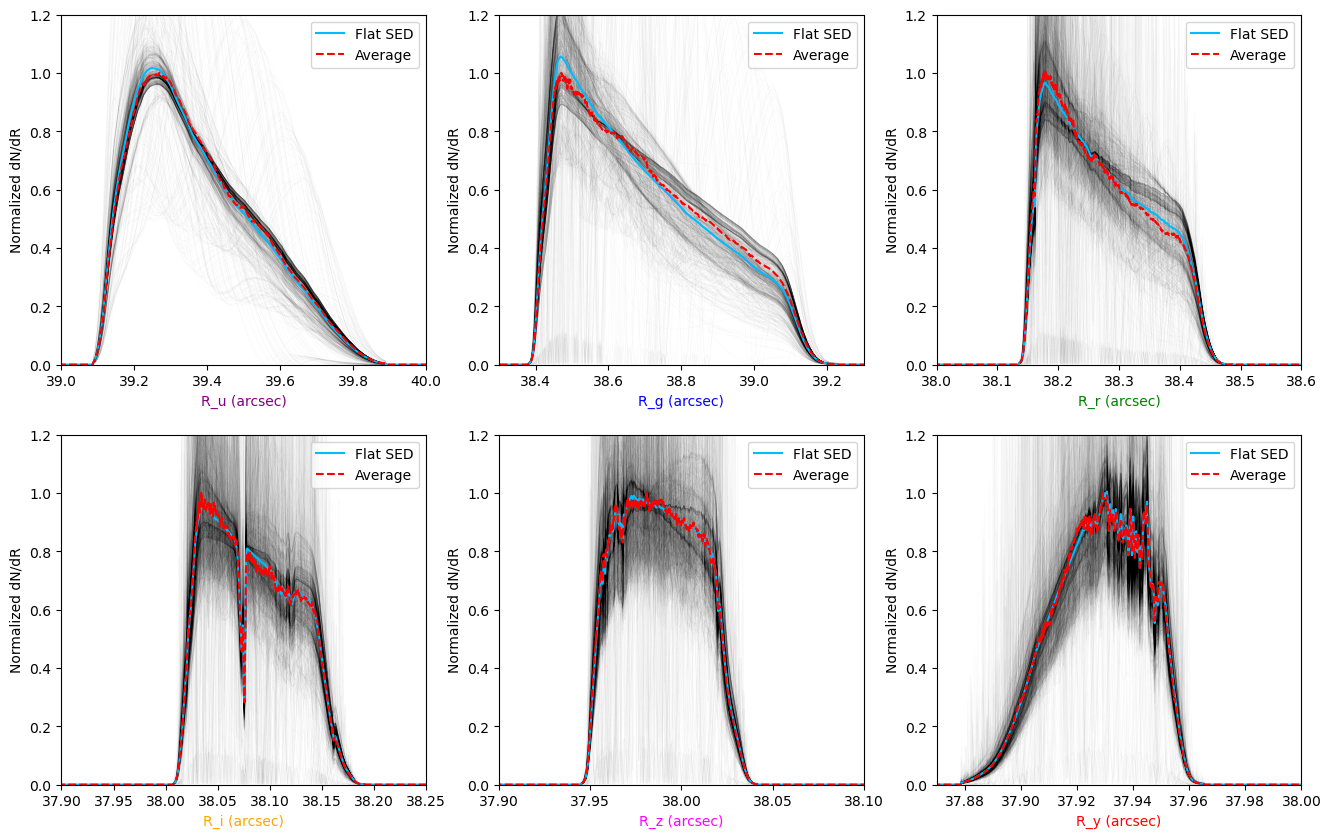

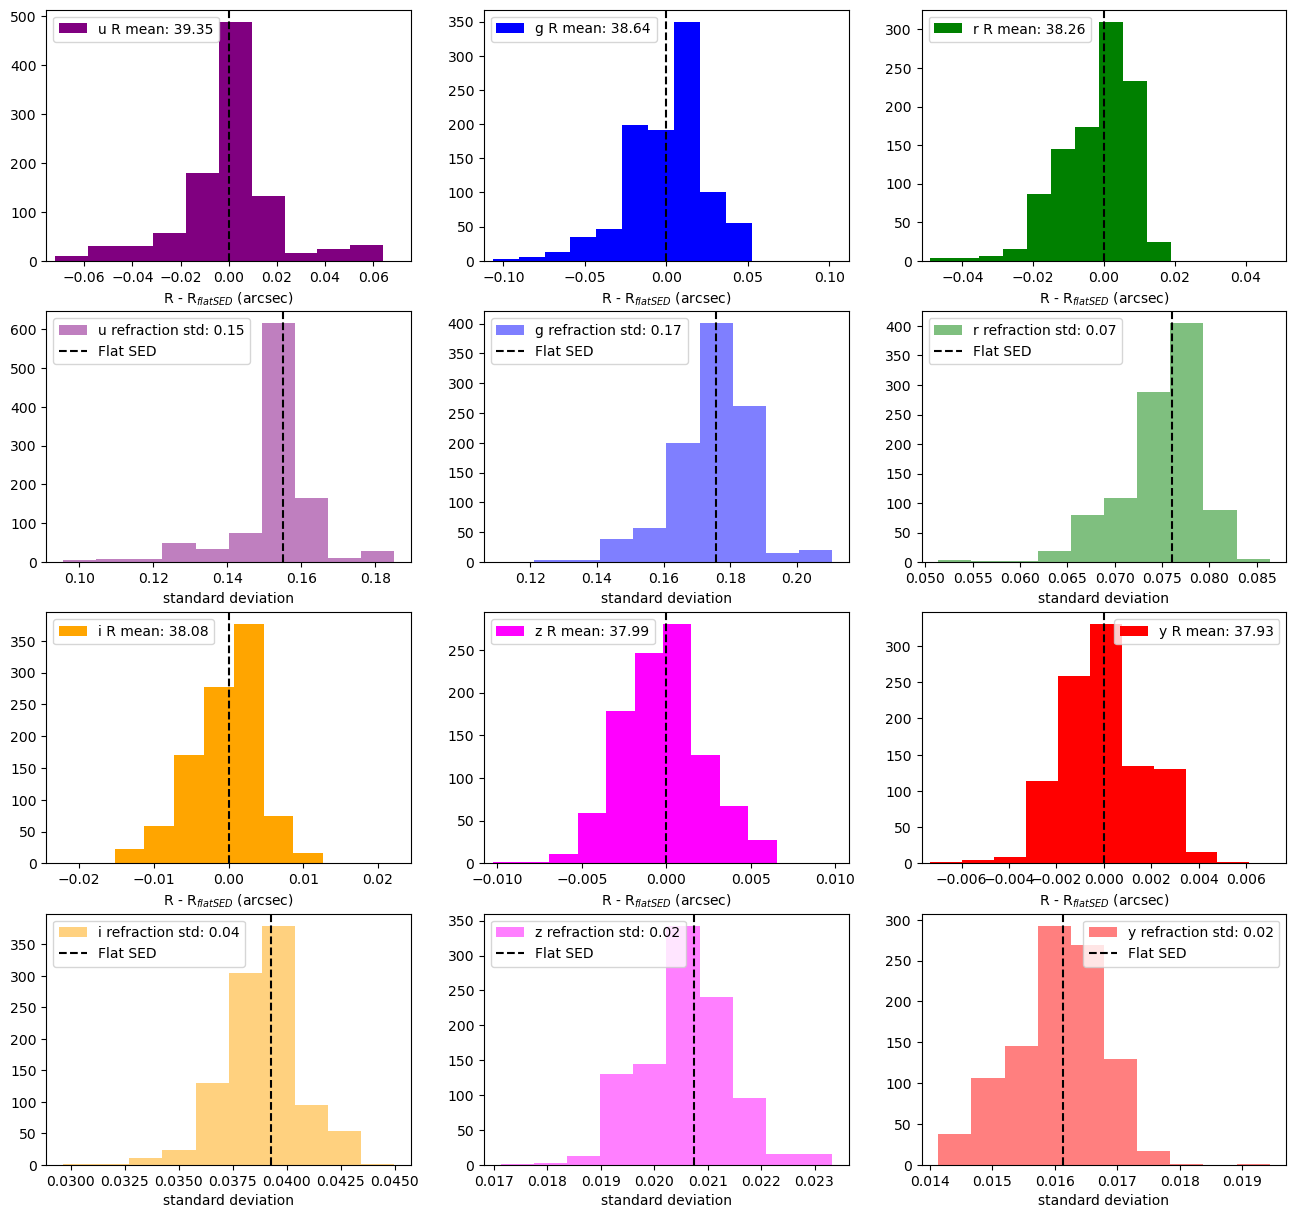

In [12]:
#Summary Plots

#defiune some axis limits for the dN/dR plots
#zenith = 35
mins = [27.25, 26.8, 26.6, 26.55, 26.5, 26.5]
maxs = [28, 27.5, 27, 26.8, 26.7, 26.6]

#zenith = 45
mins = [39, 38.3, 38, 37.9, 37.9, 37.87]
maxs = [40, 39.3, 38.6, 38.25, 38.1, 38]


def plot_refraction_distributions(refraction_angles, filtered_refracted_data, avg_dNdR, means, stdevs, mean_flatdist, stdev_flatdist):

    fig1, ax1 = plt.subplots(2, 3, figsize = (16, 10))

    fig2, ax2 = plt.subplots(4, 3, figsize = (16, 15))

    for i, band in enumerate(filter_labels):
        
        #flat dN/dR distribution 
        # width = filter_refractions[i]
        # center = refraction_centers[i]
        # flat_dist = np.zeros(len(refraction_angles))
        # mask = (refraction_angles > (center - width/2)) & (refraction_angles < (center + width/2))
        # flat_dist[mask] = 0.7

        n = i // 3
        m = i % 3

        #Flat dN/dR
        # ax1[n, m].plot(refraction_angles, flat_dist, 'b-', label = 'flat', alpha = 0.5)

        #plot all 1000 distributions on top of each other with a small alpha 
        for dist in filtered_refracted_data[band][:-1]:
            # normalized = np.abs(dist)/max(np.abs(dist))/1.2
            normalized = np.abs(dist) / np.sum(np.abs(dist)) / np.max(avg_dNdR[band])
            # summed += normalized
            ax1[n, m].plot(refraction_angles, normalized, 'k', linewidth = 0.5, alpha = 0.02)


        #test plot
        # ax1[n, m].plot(refraction_angles, filtered_refracted_data[band][-1]/max(filtered_refracted_data[band][-1])/1.2 , 'y-', label = f'flat sed')
        ax1[n, m].plot(refraction_angles, filtered_refracted_data[band][-1]/np.sum(filtered_refracted_data[band][-1]) / np.max(avg_dNdR[band] ) , '-', linewidth = 1.5, color = "#00BBFF", label = f'Flat SED')
        
        #plot the average distribution
        ax1[n, m].plot(refraction_angles, avg_dNdR[band] / np.max(avg_dNdR[band]), 'r--', linewidth = 1.5,  label = f'Average')
        ax1[n, m].legend(loc = 'upper right')
        ax1[n, m].set_xlim(mins[i], maxs[i])
        ax1[n, m].set_ylim(0, 1.2)
        ax1[n, m].set_xlabel(f'R_{band} (arcsec)', color = colors[band])
        ax1[n, m].set_ylabel('Normalized dN/dR')
        

        #plot a histogram of the means and standard deviations for each filter
        hist, bins = np.histogram(means[band] - np.mean(means['u']), 20)

        #-- log plot of the squared deviations from the mean
        # ax2[n*2, m].hist(np.log10((means[band][:-1] - np.mean(means[band][:-1]))**2), 50, label = f'{band} refraction mean: {np.round(np.mean(means[band]), 2)}', color = colors[band])

        #-- regular histogram of the 1st moment shifts
        ax2[n*2, m].hist(means[band] - mean_flatdist[band] , label = f'{band} R mean: {np.round(np.mean(means[band]), 2)}', color = colors[band])

        ax2[n*2, m].axvline(0, color = 'k', linestyle = '--')

        ax2[n*2, m].legend()
        ax2[n*2, m].set_xlabel(r'R - R$_{flat SED}$ (arcsec)')
        ax2[n*2, m].set_xlim(-np.max(np.abs(means[band] - mean_flatdist[band]))*1.05, np.max(np.abs(means[band] - mean_flatdist[band]))*1.05)

        #-- plot distribitio of standard deviations
        ax2[n*2 + 1, m].hist(stdevs[band], label = f'{band} refraction std: {np.round(np.mean(stdevs[band]), 2)}', color = colors[band], alpha = 0.5)

        ax2[n*2 + 1, m].axvline(stdev_flatdist[band], color = 'k', linestyle = '--', label = 'Flat SED')

        # ax2[n*2 + 1, m].plot(filter_refractions[i]/np.sqrt(12), 5, 'ko') #flat dN/dR stdev
        ax2[n*2 + 1, m].legend()
        ax2[n*2 + 1, m].set_xlabel('standard deviation')
        # ax2[n*2 + 1, m].set_xlim(0, filter_refractions[i]/np.sqrt(12) *1.05)
    
    
    # fig1.savefig(f'refraction_dist_plots/all.png')
    # fig1.savefig(f'refraction_dist_plots/all.pdf')


    # fig2.savefig(f'refraction_dist_plots/all_histograms.png')
    # fig2.savefig(f'refraction_dist_plots/all_histograms.pdf')

    return

# --- Plot the results (galaxy) ---
plot_refraction_distributions(refraction_angles, filtered_refracted_data, avg_dNdR, means, stdevs, mean_flatdist, stdev_flatdist)

# --- Plot the results (stellar) ---
# plot_refraction_distributions(stellar_refraction_angles, stellar_filtered_refracted_data, stellar_avg_dNdR, stellar_means, stellar_stdevs, mean_flatdist, stdev_flatdist)


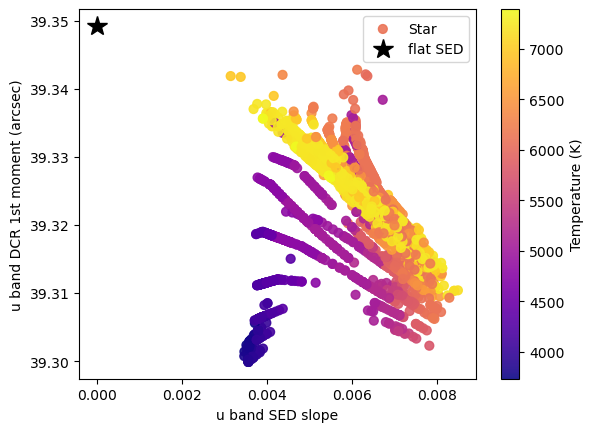

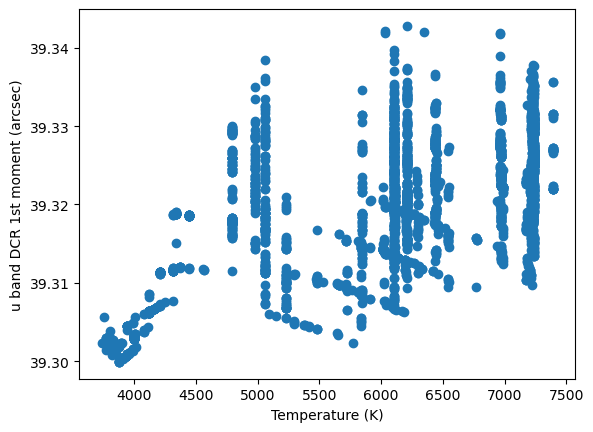

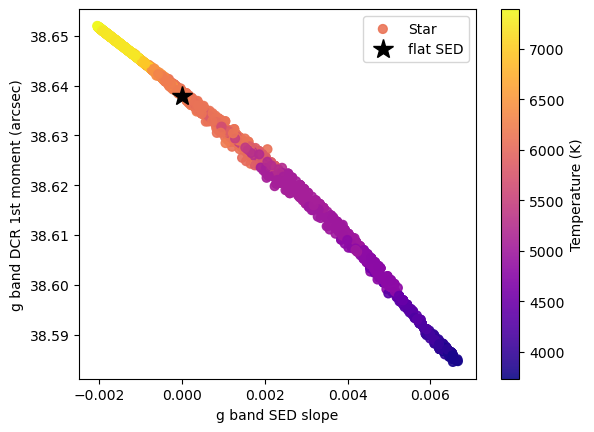

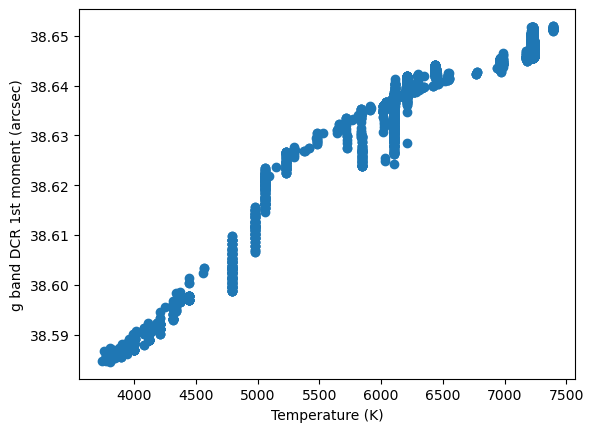

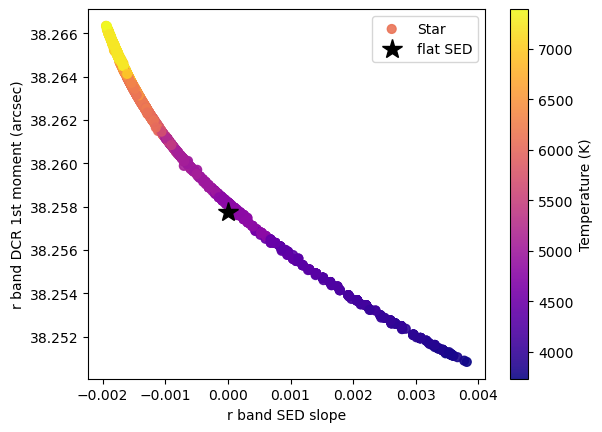

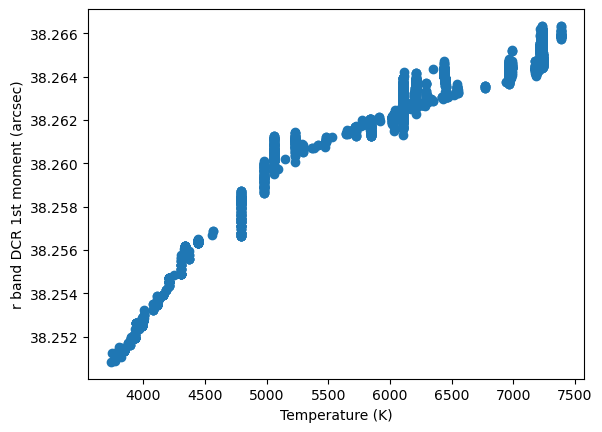

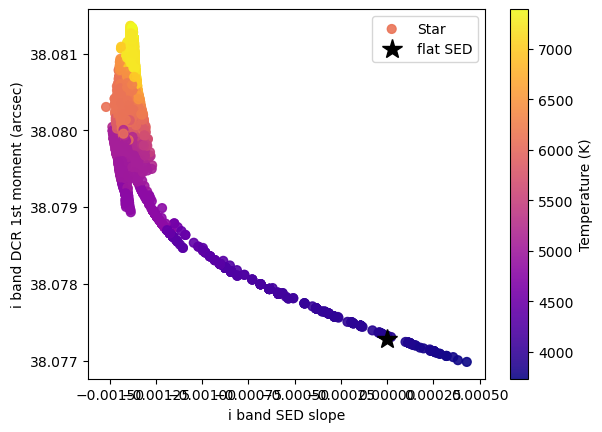

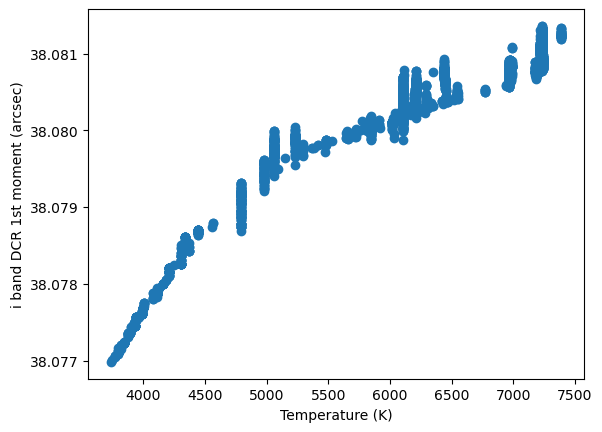

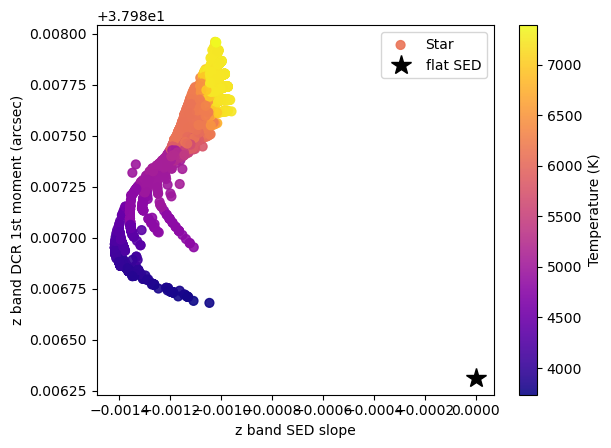

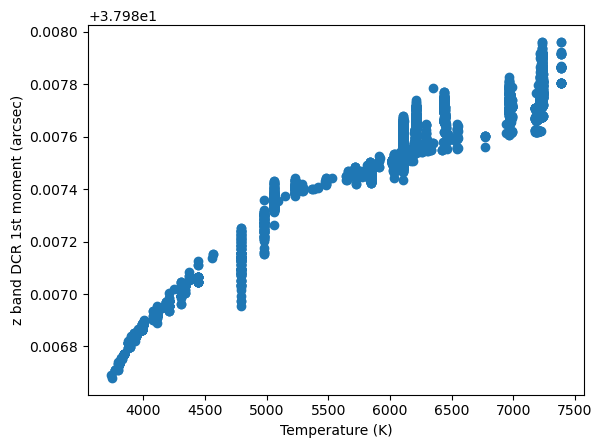

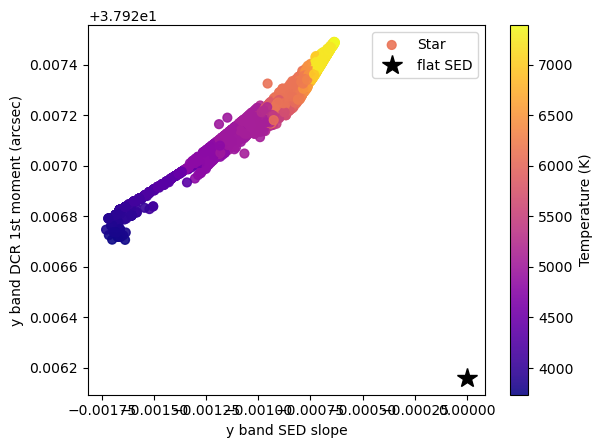

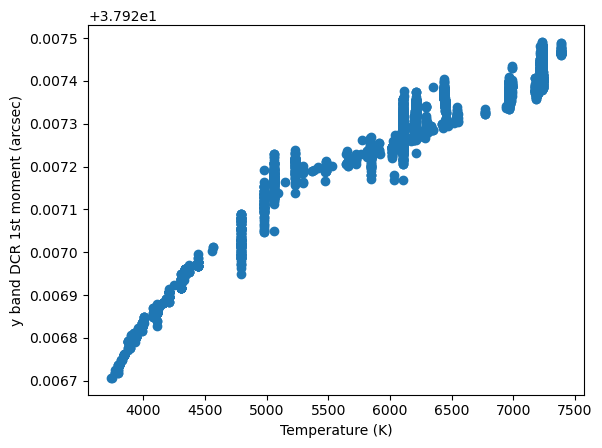

In [ ]:
# Create a scatter plot of the 1st moment DCR shift as a function of the SED slope (within a band) 

slopes = {}

band_edges = {
    'u' : [320, 400],
    'g' : [400, 552],
    'r' : [552, 691],
    'i' : [691, 818],
    'z' : [818, 922],
    'y' : [950, 1080]
} #band endges from the LSST Science Book https://www.lsst.org/sites/default/files/docs/sciencebook/SB_2.pdf

band_edges = {
    'u' : [338, 395],
    'g' : [405, 552],
    'r' : [553, 690],
    'i' : [690, 817],
    'z' : [818, 920],
    'y' : [920, 1010]
} 

for band in filter_labels:

    # Stellar SED slopes versus DCR 1st moment
    left, right = band_edges[band]
    mask = (stellar_wvl >= left) & (stellar_wvl <= right)
    band_wvl = stellar_wvl[mask]
    band_SEDs = stellar_SEDs[:, mask]

    l_edge = np.mean(band_SEDs[:, 0:10], axis = 1)
    r_edge = np.mean(band_SEDs[:, -10:], axis = 1)
    band_slopes = (r_edge - l_edge)/(right - left)

    slopes[band] = np.array(band_slopes)

    # Scatter plot of slope vs DCR 1st moment
    sc = plt.scatter(band_slopes[:-1], stellar_means[band], c = stellar_temps, cmap = 'plasma', s = 40, alpha = 0.9, label = 'Star')
    plt.plot(band_slopes[-1], mean_flatdist[band],'*', color = "#000000", markersize = 15, label = 'flat SED')
    cbar = plt.colorbar(sc)
    cbar.set_label("Temperature (K)")
    plt.xlabel(f'{band} band SED slope')
    plt.ylabel(fr'{band} band DCR 1st moment (arcsec)')
    plt.legend()
    plt.show()
    plt.close()

    # Scatter plot of temperature vs DCR 1st moment
    plt.scatter(stellar_temps, stellar_means[band])
    plt.xlabel('Temperature (K)')
    plt.ylabel(fr'{band} band DCR 1st moment (arcsec)')
    plt.show()
    plt.close()

    # i = 100
    # plt.plot(band_wvl, band_SEDs[i] - band_SEDs[i][0], 'k-')
    # plt.plot([left, right], [0, band_slopes[i]*(right - left)], 'r--')

    # plt.show()
    # plt.close()


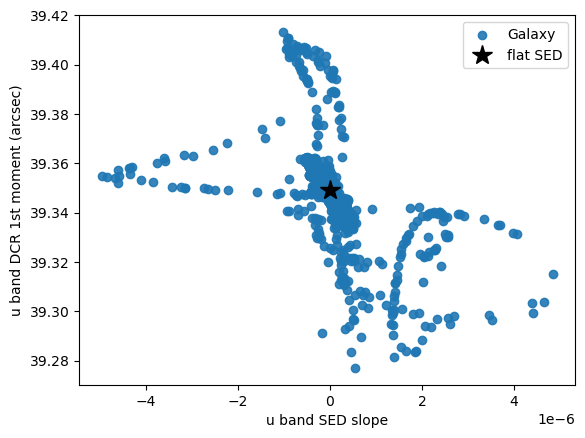

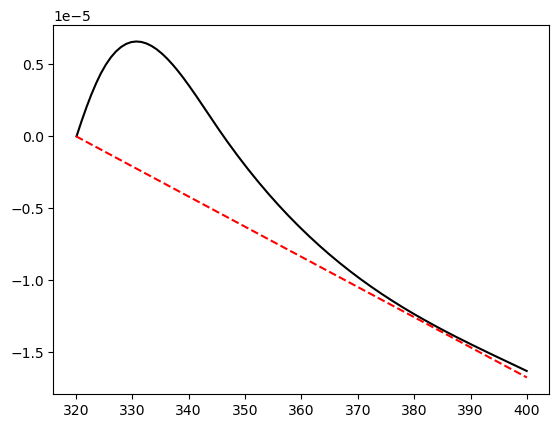

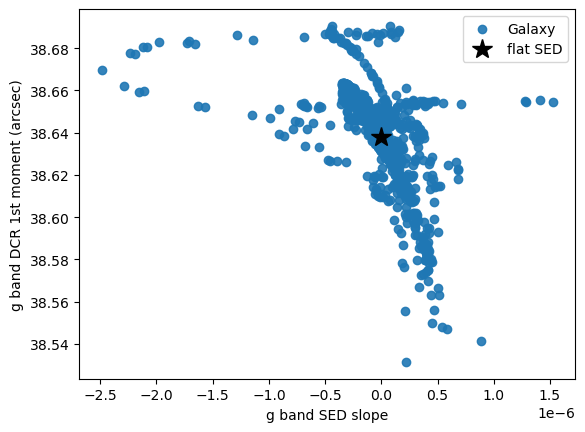

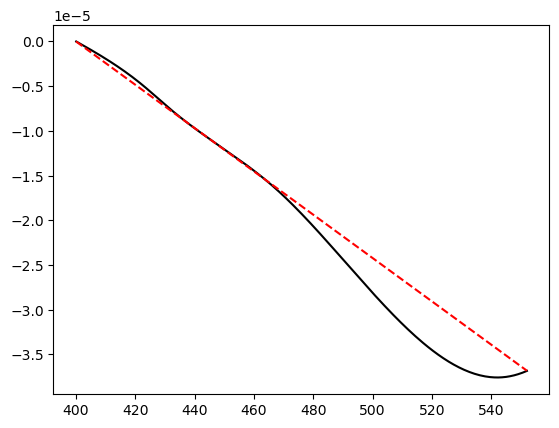

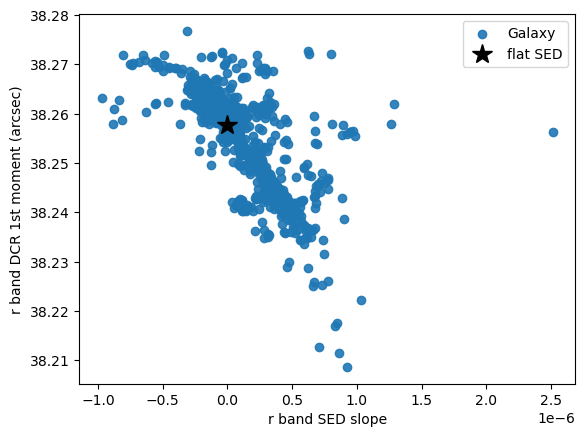

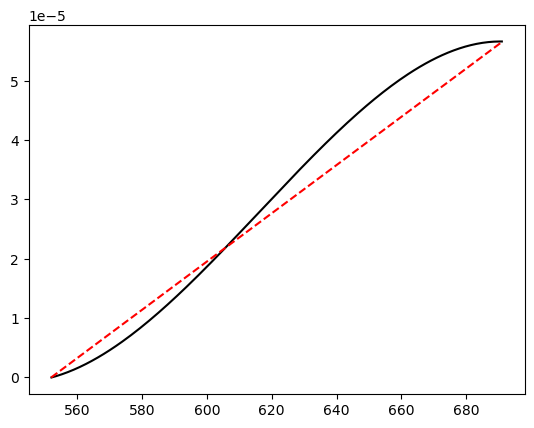

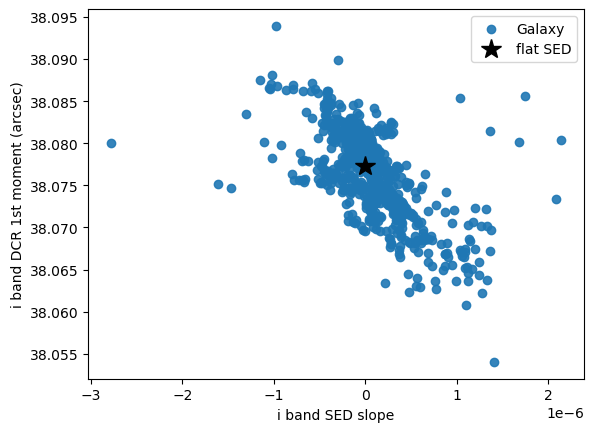

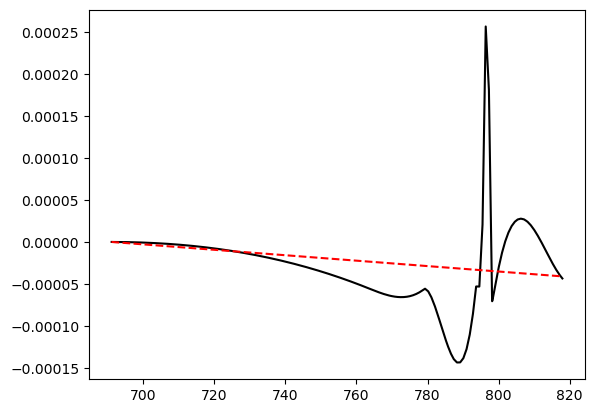

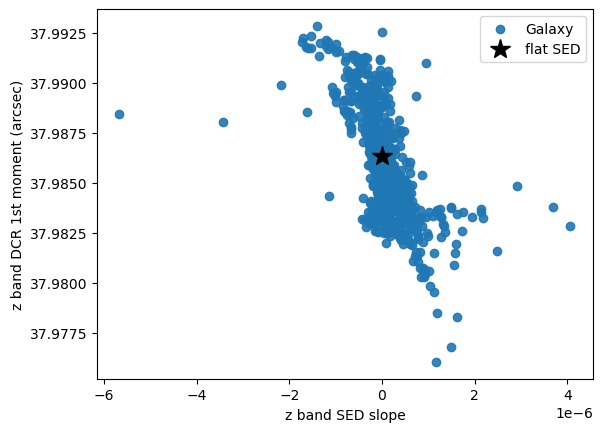

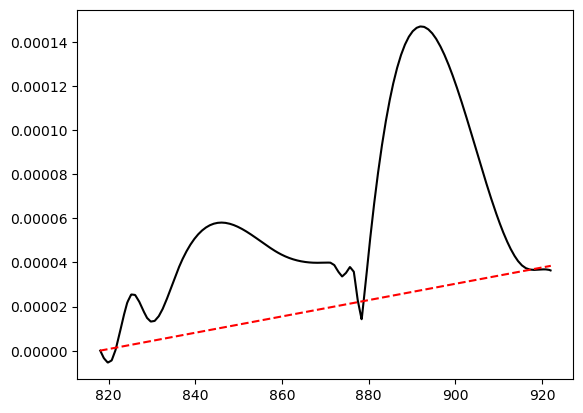

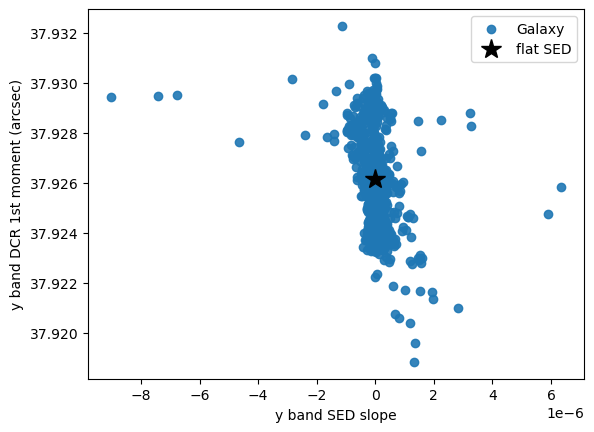

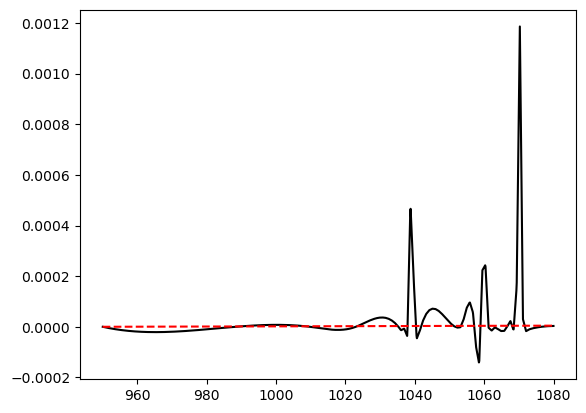

In [ ]:


# ---- Galaxy SEDs
for band in filter_labels:

    # Stellar SED slopes versus DCR 1st moment
    left, right = band_edges[band]
    mask = (wvl >= left) & (wvl <= right)
    band_wvl = wvl[mask]
    band_SEDs = SEDs[:, mask]

    l_edge = np.mean(band_SEDs[:, 0:10], axis = 1)
    r_edge = np.mean(band_SEDs[:, -10:], axis = 1)
    band_slopes = (r_edge - l_edge)/(right - left)

    slopes[band] = np.array(band_slopes)


    # Scatter plot of slope vs DCR 1st moment
    sc = plt.scatter(band_slopes[:-1], means[band], alpha = 0.9, label = 'Galaxy')
    plt.plot(band_slopes[-1], mean_flatdist[band],ls = '',  marker = '*', color = "#000000", markersize = 15, label = 'flat SED')
    plt.xlabel(f'{band} band SED slope')
    plt.ylabel(fr'{band} band DCR 1st moment (arcsec)')
    plt.legend()
    plt.show()
    plt.close()

    i = 1
    plt.plot(band_wvl, band_SEDs[i] - band_SEDs[i][0], 'k-')
    plt.plot([left, right], [0, band_slopes[i]*(right - left)], 'r--')

    plt.show()
    plt.close()


